# Alineación Semántica Texto-Texto con SBERT

**Modelo:** `sentence-transformers/all-MiniLM-L6-v2`  
**Objetivo:** Evaluar la consistencia semántica entre titulares e `img_text` (reales vs. sintéticos).


In [5]:
import json
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cpu


In [6]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
print(f"Modelo {MODEL_NAME} cargado.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo sentence-transformers/all-MiniLM-L6-v2 cargado.


In [8]:
df = pd.read_json("../../dataset/titles_img_data.jsonl", lines=True)
pairs = {}
for _, row in df.iterrows():
    gid = row["group_id"]
    label = "real" if row["is_real"] == 1 else "fake"
    if gid not in pairs:
        pairs[gid] = {}
    pairs[gid][label] = row.to_dict()
complete_pairs = {k: v for k, v in pairs.items() if "real" in v and "fake" in v}
print(f"Pares completos: {len(complete_pairs)}")

Pares completos: 877


In [9]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

@torch.no_grad()
def encode_texts(texts):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt').to(DEVICE)
    model_output = model(**encoded_input)
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    return F.normalize(sentence_embeddings, p=2, dim=1)

def cosine_sim(a, b):
    return (a @ b.T).item()

In [10]:
results = []
for gid, pair in tqdm(list(complete_pairs.items()), desc="Procesando"):
    texts = [
        pair["real"]["title"], 
        pair["fake"]["title"], 
        pair["real"]["img_text"], 
        pair["fake"]["img_text"]
    ]
    emb = encode_texts(texts)
    e_t_real = emb[0:1]
    e_t_sint = emb[1:2]
    e_i_real = emb[2:3]
    e_i_sint = emb[3:4]
    
    sim_A_real = cosine_sim(e_i_real, e_t_real)
    sim_A_sint = cosine_sim(e_i_real, e_t_sint)
    sim_B_real = cosine_sim(e_i_sint, e_t_real)
    sim_B_sint = cosine_sim(e_i_sint, e_t_sint)
    
    results.append({
        "group_id": gid,
        "title_real": texts[0],
        "title_sint": texts[1],
        "sim_A_real": sim_A_real,
        "sim_A_sint": sim_A_sint,
        "delta_A": sim_A_real - sim_A_sint,
        "sim_B_real": sim_B_real,
        "sim_B_sint": sim_B_sint,
        "delta_B": sim_B_sint - sim_B_real,
    })
res_df = pd.DataFrame(results)
res_df.to_csv("text_alignment_results.csv", index=False)
print("Resultados guardados en text_alignment_results.csv")


Procesando:   0%|          | 0/877 [00:00<?, ?it/s]

Resultados guardados en text_alignment_results.csv


In [11]:
total = len(res_df)
wins_A_real = (res_df["delta_A"] > 0).sum()
wins_B_sint = (res_df["delta_B"] > 0).sum()
print("ENFOQUE A (img_text real): Gana Titular Real ->", wins_A_real / total)
print("ENFOQUE B (img_text fake): Gana Titular Sintético ->", wins_B_sint / total)


ENFOQUE A (img_text real): Gana Titular Real -> 0.5096921322690992
ENFOQUE B (img_text fake): Gana Titular Sintético -> 0.5587229190421893


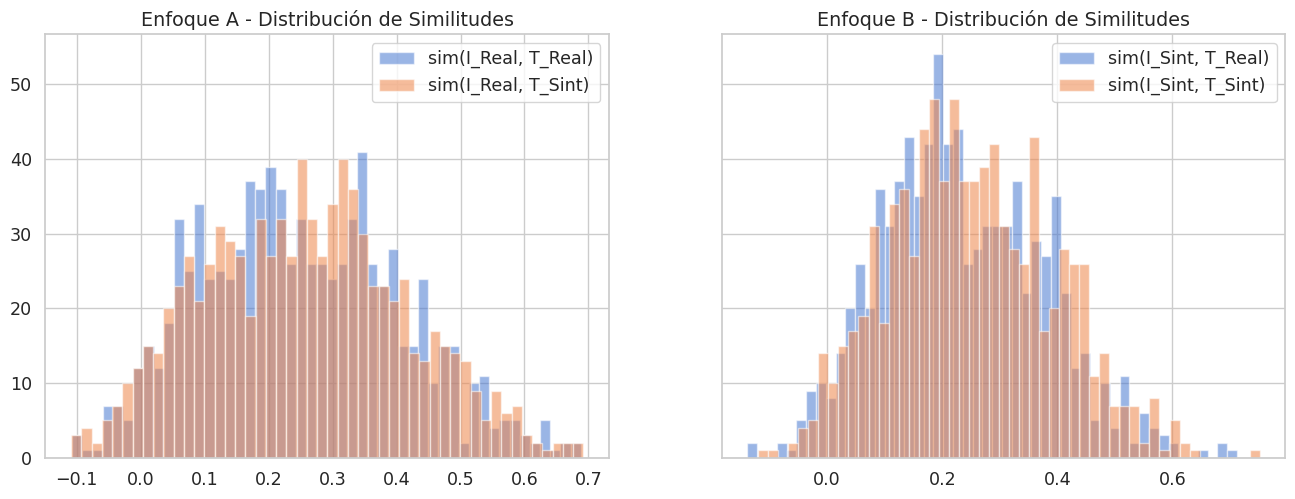

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
BINS = 50; ALPHA = 0.55
axes[0].hist(res_df["sim_A_real"], bins=BINS, alpha=ALPHA, label="sim(I_Real, T_Real)")
axes[0].hist(res_df["sim_A_sint"], bins=BINS, alpha=ALPHA, label="sim(I_Real, T_Sint)")
axes[0].set_title("Enfoque A - Distribución de Similitudes")
axes[0].legend()

axes[1].hist(res_df["sim_B_real"], bins=BINS, alpha=ALPHA, label="sim(I_Sint, T_Real)")
axes[1].hist(res_df["sim_B_sint"], bins=BINS, alpha=ALPHA, label="sim(I_Sint, T_Sint)")
axes[1].set_title("Enfoque B - Distribución de Similitudes")
axes[1].legend()
plt.savefig("text_alignment_distributions.png")
plt.show()
